### **<span style="color:purple">Car_Price Prediction ML</span>** ###

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from pandas.api.types import is_numeric_dtype
from pandas.api.types import is_object_dtype
from sklearn.linear_model import LinearRegression
from sklearn.metrics import(mean_absolute_error,mean_squared_error,r2_score)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

**<span style="color:cyan;">Data Importing</span>**

In [121]:
data=pd.read_excel(r"D:\PROJECTS\GOOGLE COLLAB\car data.xlsx")         #data importing
print(data)

      Unnamed: 0      Make          Model  ... Welcome_Lights Battery Electric_Range
0              0      Tata      Nano Genx  ...            NaN     NaN            NaN
1              1      Tata      Nano Genx  ...            NaN     NaN            NaN
2              2      Tata      Nano Genx  ...            NaN     NaN            NaN
3              3      Tata      Nano Genx  ...            NaN     NaN            NaN
4              4      Tata      Nano Genx  ...            NaN     NaN            NaN
...          ...       ...            ...  ...            ...     ...            ...
1262        1262       Bmw             X5  ...            Yes     NaN            NaN
1263        1263       Bmw             X5  ...            NaN     NaN            NaN
1264        1264  Mahindra     Alturas G4  ...            NaN     NaN            NaN
1265        1265  Mahindra     Alturas G4  ...            NaN     NaN            NaN
1266        1266   Ferrari  812 Superfast  ...            NaN    

**<span style="color:cyan;">Variable Extraction</span>**

In [122]:
#variables extraction for the prediction

df=data[['Make','Variant','Cylinders','Displacement','Fuel_Type','Height','Length','Width','Model','Body_Type','Seating_Capacity','Fuel_Tank_Capacity','ARAI_Certified_Mileage','Kerb_Weight','Gears','Ground_Clearance','Power','Torque','Type','Wheelbase','Start_/_Stop_Button','Handbrake','Airbags','ABS_(Anti-lock_Braking_System)','Ex-Showroom_Price']]

In [ ]:
#missing value detecting

mv=df.isna().sum()
print(mv)

Make                               75
Variant                             0
Cylinders                          66
Displacement                       12
Fuel_Type                           0
Height                              1
Length                              0
Width                              12
Model                               0
Body_Type                           6
Seating_Capacity                    6
Fuel_Tank_Capacity                 70
ARAI_Certified_Mileage            116
Kerb_Weight                       366
Gears                             105
Ground_Clearance                  290
Power                               0
Torque                              2
Type                                1
Wheelbase                          20
Start_/_Stop_Button               677
Handbrake                          57
Airbags                           128
ABS_(Anti-lock_Braking_System)    131
Ex-Showroom_Price                   0
dtype: int64


**<span style="color:cyan;">Duplicates Value Removal</span>**

In [124]:
#Duplicated Value

duplicates_value=df.duplicated().sum()
print(duplicates_value)
df=df.drop_duplicates()

17


In [ ]:
#Dropping Na value of Make

df = df.dropna(subset=['Make'])
df['Make'].isna().sum()

**<span style="color:cyan;">Missclassification Treatment</span>**

In [126]:
#variables missclassification treatment

#data cleaning 

df['Displacement']=df.iloc[:,3].str[:-3].astype(float)

df['Height']=df.iloc[:,5].str[:-3].astype(float)
df['Length']=df.iloc[:,6].str[:-3].astype(float)
df['Width']=df.iloc[:,7].str[:-3].astype(float)

df['Fuel_Tank_Capacity']= df['Fuel_Tank_Capacity'].str.strip("liters").astype(float)

df['ARAI_Certified_Mileage'] = df['ARAI_Certified_Mileage'].str.strip(r"\s+(km/litre|kmpl)").astype(float)

df['Kerb_Weight'] = df['Kerb_Weight'].str.strip("kg").astype(float)

df['Ground_Clearance'] = df['Ground_Clearance'].str.strip("mm").astype(float)

#Power split into two parts (Power_ps  and Power_rpm)

df["Power_ps"] = df['Power'].str.extract(
    r'(\d+\.?\d*)\s*(?:PS|ps|bhp|Bhp)',
    expand=False
).astype(float)

df["Power_rpm"] = df['Power'].str.extract(
    r'@\s*(\d+)(?:\s*-\s*(\d+))?\s*(?:rpm|RPM)'
).astype(float).mean(axis=1)

#Torque split into two parts (Torque_nm and Torque_rpm)

df["Torque_nm"] = df['Torque'].str.extract(
    r'(\d+\.?\d*)\s*(?:nm|NM|Nm)',
    expand=False
).astype(float)

df["Torque_rpm"] = df["Torque"].str.extract(
    r'@\s*(\d+)(?:\s*-\s*(\d+))?\s*(?:rpm|RPM|Rpm)'
).astype(float).mean(axis=1)

df['Wheelbase'] = df['Wheelbase'].str.strip(r'(MM|Mm)').astype(float)

df['Ex-Showroom_Price']=df.iloc[:,24].str[3:]

df['Ex-Showroom_Price']=df.iloc[:,24].str.replace(',' ,'',regex=False).astype(float)

df['Seating_Capacity']=df['Seating_Capacity'].astype(str)

df['Gears']=df['Gears'].replace("Single Speed Reduction Gear",'1')

df['Gears']=df['Gears'].replace("7 Dual Clutch",'7').astype(float)

df['Variant']=df['Variant'].astype(str)

df['Model'] = df['Model'].astype(str)

In [127]:
#dropping power and Torque

df=df.drop(columns=['Power' , 'Torque'])

In [128]:
df["Log_Price"] = np.log(df['Ex-Showroom_Price'])

**<span style="color:cyan;">Splitting Data(Train and Test)</span>**

In [129]:
#SPLITTING THE DATA INTO TRAIN TEST SPLIT

x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['Log_Price','Ex-Showroom_Price']),df['Log_Price'],test_size=0.2,random_state=42)
print(y_test)

704     13.638773
427     14.602148
192     13.510886
209     13.548937
787     13.629181
          ...    
352     13.815411
43      13.334268
494     15.538634
1266    17.766754
331     13.774543
Name: Log_Price, Length: 235, dtype: float64


In [130]:
#Checking the Data Types of all columns

print(x_train.dtypes)

Make                                  str
Variant                               str
Cylinders                         float64
Displacement                      float64
Fuel_Type                             str
Height                            float64
Length                            float64
Width                             float64
Model                                 str
Body_Type                             str
Seating_Capacity                      str
Fuel_Tank_Capacity                float64
ARAI_Certified_Mileage            float64
Kerb_Weight                       float64
Gears                             float64
Ground_Clearance                  float64
Type                                  str
Wheelbase                         float64
Start_/_Stop_Button                   str
Handbrake                             str
Airbags                               str
ABS_(Anti-lock_Braking_System)        str
Power_ps                          float64
Power_rpm                         

**<span style="color:cyan;">Missing Value Treatment</span>**

In [131]:
#Replacing the na value with appropriate data

def na_repl(train,test):
    train[['Start_/_Stop_Button' , 'ABS_(Anti-lock_Braking_System)']] = train[['Start_/_Stop_Button' , 'ABS_(Anti-lock_Braking_System)']].fillna('No')
    test[['Start_/_Stop_Button' , 'ABS_(Anti-lock_Braking_System)']] = test[['Start_/_Stop_Button' , 'ABS_(Anti-lock_Braking_System)']].fillna('No')
    for col in train.columns:
        if is_numeric_dtype(train[col]):
            value=train[col].mean().round(2)
        else:
            value=train[col].mode()[0]

        train[col]=train[col].fillna(value)
        test[col]=test[col].fillna(value)

    return train,test

x_train , x_test=na_repl(x_train,x_test)

In [132]:
#Verifying the treatment of all na value

x_train.isna().sum()

Make                              0
Variant                           0
Cylinders                         0
Displacement                      0
Fuel_Type                         0
Height                            0
Length                            0
Width                             0
Model                             0
Body_Type                         0
Seating_Capacity                  0
Fuel_Tank_Capacity                0
ARAI_Certified_Mileage            0
Kerb_Weight                       0
Gears                             0
Ground_Clearance                  0
Type                              0
Wheelbase                         0
Start_/_Stop_Button               0
Handbrake                         0
Airbags                           0
ABS_(Anti-lock_Braking_System)    0
Power_ps                          0
Power_rpm                         0
Torque_nm                         0
Torque_rpm                        0
dtype: int64

In [133]:
print(y_test)

704     13.638773
427     14.602148
192     13.510886
209     13.548937
787     13.629181
          ...    
352     13.815411
43      13.334268
494     15.538634
1266    17.766754
331     13.774543
Name: Log_Price, Length: 235, dtype: float64


## **<span style="color:Purple;">Encoding</span>** ##

In [134]:
#Encoding

ohe=OneHotEncoder(                                             #Ohe (object)
    sparse_output=False,                                       #prevent to giving the sparse matrix
    handle_unknown='ignore',
    drop='first',                                   
    dtype=np.int32
)

encoded_array = ohe.fit_transform(                            #fitted the ohe function for train data

    x_train[['Fuel_Type' , 'Type' , 'Handbrake' , 'Start_/_Stop_Button' , 'ABS_(Anti-lock_Braking_System)']]
)

x_train_new = pd.DataFrame(                                   #Creating Data Frames
    encoded_array,
    columns= ohe.get_feature_names_out(['Fuel_Type' , 'Type' , 'Handbrake' , 'Start_/_Stop_Button' , 'ABS_(Anti-lock_Braking_System)']),
    index=x_train.index
)

encoded_array1=ohe.transform(                           #fitted the ohe function for test data

        x_test[['Fuel_Type' , 'Type' , 'Handbrake' , 'Start_/_Stop_Button' , 'ABS_(Anti-lock_Braking_System)']]
)

x_test_new = pd.DataFrame(                                   #Creating Data Frames
    encoded_array1,
    columns= ohe.get_feature_names_out(['Fuel_Type' , 'Type' , 'Handbrake' , 'Start_/_Stop_Button' , 'ABS_(Anti-lock_Braking_System)']),
    index=x_test.index
)

Ed_x_train=np.hstack((x_train.drop(columns=['Make','Model','Variant','Airbags','Body_Type','Fuel_Type' , 'Type' , 'Handbrake' , 'Start_/_Stop_Button' , 'ABS_(Anti-lock_Braking_System)']).values, x_train_new))                            #Rehstake the transform data (trian)

Ed_x_test=np.hstack((x_test.drop(columns=['Make','Model','Variant','Airbags','Body_Type','Fuel_Type' , 'Type' , 'Handbrake' , 'Start_/_Stop_Button' , 'ABS_(Anti-lock_Braking_System)']).values , x_test_new))                              #Rehstake the transform data (test)


In [135]:
#Grouping into two parts columns

#////////************ Make ****************/////////

counts_mk=x_train['Make'].value_counts()                            #counting the frequency of the variant

threshold_mk=50                                                

repl_mk=counts_mk[counts_mk <= threshold_mk].index                      #split the data according to threshold

gp_mk_train=pd.get_dummies(x_train['Make'].replace(repl_mk,"Uncommon_mk"),drop_first=True)         #Highest frequency - Remain , Low-frequency - Grouped in Uncommon
gp_mk_test=pd.get_dummies(x_test['Make'].replace(repl_mk,"Uncommon_mk"),drop_first=True)

#////////************ Variant ****************/////////

counts_var=x_train['Variant'].value_counts()

threshold_vr = 5

repl_var = counts_var[counts_var <= threshold_vr].index

gp_var_train=pd.get_dummies(x_train['Variant'].replace(repl_var,"Uncommon_var"),drop_first=True)
gp_var_test=pd.get_dummies(x_test['Variant'].replace(repl_var,"Uncommon_var"),drop_first=True)

#////////************ Airbags ****************/////////

counts_air=x_train['Airbags'].value_counts()

threshold_air= 30

repl_air = counts_air[counts_air <= threshold_air].index

gp_air_train=pd.get_dummies(x_train['Airbags'].replace(repl_air,"Uncommon_air"),drop_first=True)
gp_air_test=pd.get_dummies(x_test['Airbags'].replace(repl_air,"Uncommon_air"),drop_first=True)

#////////************ Body_Type ****************//////////

counts_bt=x_train['Body_Type'].value_counts()

threshold_bt= 50

repl_bt = counts_bt[counts_bt <= threshold_bt].index

gp_bt_train = pd.get_dummies(x_train['Body_Type'].replace(repl_bt,"Uncommon_bt"),drop_first=True)
gp_bt_test = pd.get_dummies(x_test['Body_Type'].replace(repl_bt,"Uncommon_bt"),drop_first=True)

#////////************ Body_Type ****************//////////

counts_md = x_train['Model'].value_counts()

threshold_md=15

repl_md = counts_md[counts_md <= threshold_md].index

gp_md_train = pd.get_dummies(x_train['Model'].replace(repl_md,"Uncommon_md"),drop_first=True)
gp_md_test = pd.get_dummies(x_test['Model'].replace(repl_md , "Uncommon_md"),drop_first=True)

In [136]:
#alingment of test dummy variable

gp_mk_test = gp_mk_test.reindex(columns=gp_mk_train.columns, fill_value=0)
gp_var_test = gp_var_test.reindex(columns=gp_var_train.columns, fill_value=0)
gp_air_test = gp_air_test.reindex(columns=gp_air_train.columns, fill_value=0)
gp_bt_test = gp_bt_test.reindex(columns=gp_bt_train.columns, fill_value=0)
gp_md_test = gp_md_test.reindex(columns=gp_md_train.columns , fill_value=0)

**<span style="color:cyan;">Combining the all encoded columns and numeric column</span>**

In [137]:
#Combining the all encoded columns and numeric column

Train_model=pd.concat(
        [
            pd.DataFrame(Ed_x_train,index=x_train.index),
            gp_mk_train,
            gp_var_train,
            gp_air_train,
            gp_bt_train,
            gp_md_train,
        
        ],
        axis=1

)

In [138]:

#////////************ Test Model ****************//////////

Test_model=pd.concat(
        [
            pd.DataFrame(Ed_x_test,index=x_test.index),
            gp_mk_test,
            gp_var_test,
            gp_air_test,
            gp_bt_test,
            gp_md_test,
        
        ],
        axis=1

)

In [139]:
Train_model.columns = Train_model.columns.astype(str)
Test_model.columns = Test_model.columns.astype(str)

In [140]:
print(Train_model.shape)
print(Test_model.shape)
print(Train_model.columns.equals(Test_model.columns))
print(Train_model.isna().sum().sum())
print(Test_model.isna().sum().sum())

(940, 45)
(235, 45)
True
0
0


**<span style="color:cyan;">Object Transformation</span>**

In [141]:
#Object transformation

def obj_tr(train , test):
    for col in train.columns:
        if is_object_dtype(train[col]):
            train[col] = train[col].astype(str)
            test[col] = test[col].astype(str)

    return train , test


Train_model , Test_model = obj_tr(Train_model , Test_model)

In [142]:
print(Train_model.dtypes[Train_model.dtypes == "object"])

Series([], dtype: object)


**<span style="color:cyan;">Graph</span>**

<function matplotlib.pyplot.show(close=None, block=None)>

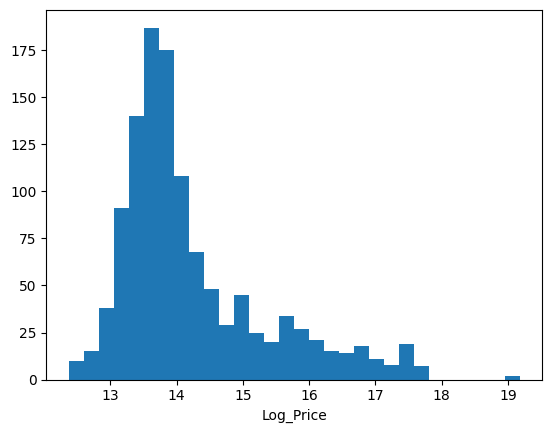

In [143]:
plt.hist(df['Log_Price'], bins=30)
plt.title("")
plt.xlabel("Log_Price")
plt.autoscale()
plt.show

In [144]:
print(Train_model.dtypes[Train_model.dtypes == 'object'])

Series([], dtype: object)


**<span style="color:cyan;">Linear Regression Model</span>**

In [145]:
#Model applyied

model=LinearRegression()

lr=model.fit(Train_model,y_train)

y_pred=model.predict(Test_model)

**<span style="color:cyan;">Model Evaluation</span>**

In [146]:
#Evaluat the model

mse = mean_squared_error(y_test , y_pred)

mae = mean_absolute_error(y_test , y_pred)

rmse = np.sqrt(mse)         

r2_square = r2_score(y_test , y_pred)

print("LR Mean Absolute Error : ",mae)
print("LR Mean Squared Error :",mse)
print("LR Root Mean Squared Error :",rmse)
print("LR R2_Score :",r2_square)

LR Mean Absolute Error :  0.2640531001525132
LR Mean Squared Error : 0.1094819395750506
LR Root Mean Squared Error : 0.3308805518235404
LR R2_Score : 0.9188347341115032


In [147]:
accuracy = (1 - mean_absolute_error(y_test, y_pred) / y_test.mean()) * 100
print(f"Approximate Accuracy: {accuracy:.2f}%")

Approximate Accuracy: 98.15%


**<span style ="color:cyan">Plotting Predicted and Actual variable</span>**

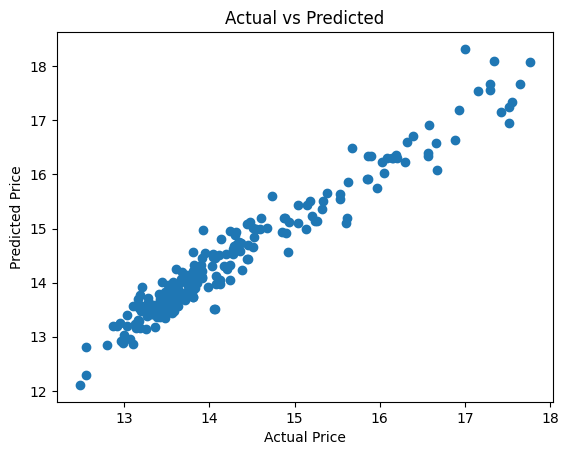

In [148]:
#PLOTTING THE PREDICTED AND ACTUAL VARIABLE

plt.scatter(y_test,y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

**<span style="color:cyan">Residual Plotting</span>**

<function matplotlib.pyplot.show(close=None, block=None)>

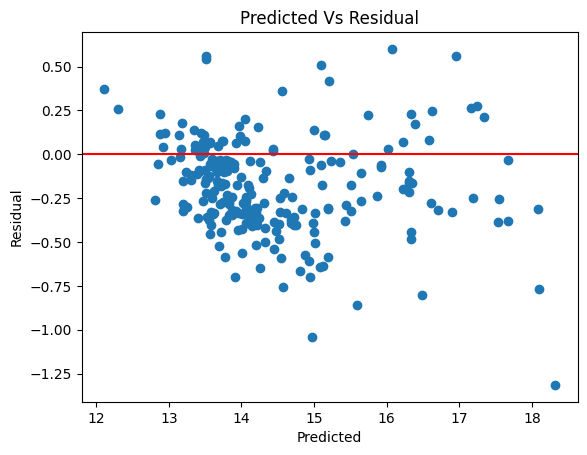

In [149]:
#checking residual error

residual = y_test - y_pred

plt.scatter(y_pred , residual)
plt.axhline(y=0, color='red')
plt.title("Predicted Vs Residual")
plt.ylabel("Residual")
plt.xlabel("Predicted")
plt.show


In [150]:
coef = pd.DataFrame({
    "Feature": Train_model.columns,
    "Coefficient": lr.coef_
})

**<span style="color:cyan">Predicted and Actual Price</span>**

In [151]:
for i in range(10):
    pred = lr.predict(Test_model.iloc[[i]])[0]
    actual = y_test.iloc[i]

    pred = np.exp(pred).round(2)
    actual = np.exp(actual).round(2)
    print(f"Car {i+1}")
    print("LR Predicted:", pred)
    print("LR Actual   :", actual)
    print()

Car 1
LR Predicted: 780225.95
LR Actual   : 838000.0

Car 2
LR Predicted: 3938893.43
LR Actual   : 2196000.0

Car 3
LR Predicted: 856632.62
LR Actual   : 737400.0

Car 4
LR Predicted: 712302.95
LR Actual   : 766000.0

Car 5
LR Predicted: 1060793.77
LR Actual   : 830000.0

Car 6
LR Predicted: 3263211.53
LR Actual   : 3740000.0

Car 7
LR Predicted: 2545844.44
LR Actual   : 1699000.0

Car 8
LR Predicted: 2894593.33
LR Actual   : 1628000.0

Car 9
LR Predicted: 667979.61
LR Actual   : 610000.0

Car 10
LR Predicted: 847434.07
LR Actual   : 816500.0



**<span style="color:cyan">Decision Tree Model</span>**

In [152]:
#Decision Tree Model

dt_model=DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(Train_model , y_train)

dt_pred=dt_model.predict(Test_model)


In [153]:
#Evaluate the Model

dt_mse = mean_absolute_error(y_test , dt_pred)

dt_mae = mean_squared_error(y_test , dt_pred)

dt_rmse = np.sqrt(mse)

dt_r2_square = r2_score(y_test , dt_pred)

print("DT Mean Absolute Error :" , dt_mae)
print("DT Mean Squared Error :",dt_mse)
print("DT Root Mean Squared Error :",dt_rmse)
print("DT R2_Square : ",dt_r2_square)

DT Mean Absolute Error : 0.03052907360766628
DT Mean Squared Error : 0.1132324063285439
DT Root Mean Squared Error : 0.3308805518235404
DT R2_Square :  0.977367039839506


In [154]:
accuracy = (1 - mean_absolute_error(y_test, dt_pred) / y_test.mean()) * 100
print(f"Approximate Accuracy: {accuracy:.2f}%")

Approximate Accuracy: 99.21%


In [155]:
for i in range(10):
    pred = dt_model.predict(Test_model.iloc[[i]])[0]
    actual=y_test.iloc[i]

    pred = np.exp(pred).round(2)
    actual = np.exp(actual).round(2)

    print(f"car {i+1} :")
    print("Decision Tree Predicted Price : ",pred)
    print("Decision Tree Actual Price : ",actual)
    print()

car 1 :
Decision Tree Predicted Price :  836400.0
Decision Tree Actual Price :  838000.0

car 2 :
Decision Tree Predicted Price :  1888000.0
Decision Tree Actual Price :  2196000.0

car 3 :
Decision Tree Predicted Price :  802000.0
Decision Tree Actual Price :  737400.0

car 4 :
Decision Tree Predicted Price :  816000.0
Decision Tree Actual Price :  766000.0

car 5 :
Decision Tree Predicted Price :  980000.0
Decision Tree Actual Price :  830000.0

car 6 :
Decision Tree Predicted Price :  4390000.0
Decision Tree Actual Price :  3740000.0

car 7 :
Decision Tree Predicted Price :  2079599.0
Decision Tree Actual Price :  1699000.0

car 8 :
Decision Tree Predicted Price :  1498000.0
Decision Tree Actual Price :  1628000.0

car 9 :
Decision Tree Predicted Price :  558103.93
Decision Tree Actual Price :  610000.0

car 10 :
Decision Tree Predicted Price :  623000.0
Decision Tree Actual Price :  816500.0



**<span style="color:cyan">Random Forest Model</span>**

In [156]:
#Random Forest Prediction Model

Rfp = RandomForestRegressor()

Rfp_model = Rfp.fit(Train_model , y_train)

Rfp_pred = Rfp.predict(Test_model)

In [157]:
#Evaluate the model

Rfp_mse = mean_squared_error(y_test , Rfp_pred)

Rfp_mae = mean_absolute_error(y_test , Rfp_pred)

Rfp_rmse = np.sqrt(Rfp_mse)

Rfp_r2 = r2_score(y_test , Rfp_pred)

print("Random Forest Mean Squared Error : ",Rfp_mse)
print("Random Forest Mean Absolute Error : ",Rfp_mae)
print("Random Forest Root Mean Squared Error : ",Rfp_rmse)
print("Random Forest R2 Square : ",Rfp_r2)

Random Forest Mean Squared Error :  0.020122270641896013
Random Forest Mean Absolute Error :  0.09556594833603735
Random Forest Root Mean Squared Error :  0.14185298954162373
Random Forest R2 Square :  0.9850822021123384


In [158]:
accuracy = (1 - mean_absolute_error(y_test, Rfp_pred) / y_test.mean()) * 100
print(f"Approximate Accuracy: {accuracy:.2f}%")

Approximate Accuracy: 99.33%


In [159]:
for i in range(10):
    pred = Rfp_model.predict(Test_model.iloc[[i]])[0]
    actual = y_test.iloc[i]

    pred = np.exp(pred).round(2)
    actual = np.exp(actual).round(2)

    print(f"Car {i+1} :")
    print("RF Predicted Price :",pred)
    print("RF Actual Price :",actual)
    print()

Car 1 :
RF Predicted Price : 820542.9
RF Actual Price : 838000.0

Car 2 :
RF Predicted Price : 2257948.22
RF Actual Price : 2196000.0

Car 3 :
RF Predicted Price : 679268.46
RF Actual Price : 737400.0

Car 4 :
RF Predicted Price : 786349.01
RF Actual Price : 766000.0

Car 5 :
RF Predicted Price : 938596.81
RF Actual Price : 830000.0

Car 6 :
RF Predicted Price : 3851566.43
RF Actual Price : 3740000.0

Car 7 :
RF Predicted Price : 2004051.3
RF Actual Price : 1699000.0

Car 8 :
RF Predicted Price : 1532804.36
RF Actual Price : 1628000.0

Car 9 :
RF Predicted Price : 573182.15
RF Actual Price : 610000.0

Car 10 :
RF Predicted Price : 800181.98
RF Actual Price : 816500.0



**<sapn style="color:cyan">Exporting Cleaned Data</span>**

In [160]:
#Exporting clean data

def exp_exc(df):
    df[['Start_/_Stop_Button' , 'ABS_(Anti-lock_Braking_System)']] = df[['Start_/_Stop_Button' , 'ABS_(Anti-lock_Braking_System)']].fillna('No')

    for col in df.columns:
        if is_numeric_dtype(df[col]):
            value = df[col].mean().round(2)

        else:
            value=df[col].mode()[0]

        df[col] = df[col].fillna(value)

    return df

df = exp_exc(df)

#df.to_excel(
#    r"D:\PROJECTS\GOOGLE COLLAB\cleaned_car_datasheet.xlsx",
#    index=False
#)